In [23]:
import numpy as np

# definir les filtres RGB (simplifies)
def rgb_filters(wavelengths):
    r_filter = np.exp(-0.5 * ((wavelengths - 575) / 50) ** 2)
    g_filter = np.exp(-0.5 * ((wavelengths - 535) / 50) ** 2)
    b_filter = np.exp(-0.5 * ((wavelengths - 445) / 50) ** 2)
    return np.vstack([r_filter, g_filter, b_filter])


# generer un faux spectre de reflectance
def generate_spectrum(c1, n_wavelengths=31):
    wavelengths = np.linspace(400, 700, n_wavelengths)
    width = 30
    amplitude = 1
    spectrum = np.exp(-0.5 * ((wavelengths - c1) / width) ** 2) * amplitude

    filters = rgb_filters(wavelengths)
    rgb_raw = filters @ spectrum
    rgb = 2*rgb_raw / np.sum(filters[1]) # bricolage
    #np.max(rgb_raw) if np.max(rgb_raw) > 0 else rgb_raw

    patch = np.tile(np.clip((255 * rgb), 0, 255).astype(np.uint8), (90, 90, 1))
    return wavelengths, spectrum, filters, rgb, patch

import plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots
# white theme
plotly.io.templates.default = "plotly_white"

center_values = np.linspace(430, 650, 10)
wavelengths, spectrum, filters, rgb, patch = generate_spectrum(center_values[0])

fig = make_subplots(
  rows=1,
  cols=3,
  column_widths=[0.62, 0.2, 0.18],
  specs=[[{"type": "xy"}, {"type": "xy"}, {"type": "image"}]],
  subplot_titles=("", "Projection RGB", "Couleur reconstruite"),
  horizontal_spacing=0.08,
)

# remove grid on the first subplot
fig.update_xaxes(showgrid=False, row=1, col=1)
fig.update_yaxes(showgrid=False, row=1, col=1)

# trace 0: spectre mobile
fig.add_trace(
  go.Scatter(
    x=wavelengths,
    y=spectrum,
    mode="lines",
    name="Gaussienne mobile",
    line=dict(color="black", width=3),
  ),
  row=1,
  col=1,
)
# traces 1..3: filtres fixes
fig.add_trace(
  go.Scatter(x=wavelengths, y=filters[0], mode="lines", name="Filtre R", line=dict(color="red", dash="dash"), opacity=0.35),
  row=1,
  col=1,
)
fig.add_trace(
  go.Scatter(x=wavelengths, y=filters[1], mode="lines", name="Filtre G", line=dict(color="green", dash="dash"), opacity=0.35),
  row=1,
  col=1,
)
fig.add_trace(
  go.Scatter(x=wavelengths, y=filters[2], mode="lines", name="Filtre B", line=dict(color="blue", dash="dash"), opacity=0.35),
  row=1,
  col=1,
)

# trace 4: barres RGB
fig.add_trace(
  go.Bar(x=["R", "G", "B"], y=rgb, marker_color=["red", "green", "blue"], showlegend=False),
  row=1,
  col=2,
)
# trace 5: patch couleur
fig.add_trace(
  go.Image(z=patch, hovertemplate="R=%{z[0]}<br>G=%{z[1]}<br>B=%{z[2]}<extra></extra>"),
  row=1,
  col=3,
)

frames = []
for c1 in center_values:
  wavelengths, spectrum, filters, rgb, patch = generate_spectrum(c1)
  frames.append(
    go.Frame(
      name=f"{c1:.0f}",
      data=[
        go.Scatter(x=wavelengths, y=spectrum),
        go.Bar(x=["R", "G", "B"], y=rgb),
        go.Image(z=patch),
      ],
      # Update only traces 0 (spectre), 4 (barres), 5 (image)
      traces=[0, 4, 5],
    )
  )

fig.frames = frames

fig.update_xaxes(title_text="Longueur d'onde (nm)", row=1, col=1)
fig.update_yaxes(title_text="Intensite", row=1, col=1)
fig.update_yaxes(range=[0, 1.1], row=1, col=2)
fig.update_xaxes(showgrid=False, visible=False, row=1, col=3)
fig.update_yaxes(showgrid=False, visible=False, row=1, col=3)

fig.update_layout(
  height=420,
  margin=dict(l=20, r=20, t=70, b=20),
  legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
  sliders=[
    dict(
      active=0,
      currentvalue={"prefix": "Centre spectre : "},
      pad={"t": 20},
      steps=[
        dict(
          label=f"{c1:.0f} nm",
          method="animate",
          args=[
            [f"{c1:.0f}"],
            {
              "mode": "immediate",
              "frame": {"duration": 0, "redraw": True},
              "transition": {"duration": 0},
            },
          ],
        )
        for c1 in center_values
      ],
    )
  ],
)

fig

Code for generating the cat image beforehand, to avoid reconstruction at runtime for slides (will still do the NMF live)

In [41]:
import torch, torchvision
from spyrit.core.meas import HadamSplit2d
from spyrit.core.noise import Poisson
import matplotlib.pyplot as plt
import tensorly as tl
import numpy as np
from tensorly_hdr.nmf_kl import MU_SinglePixel
from tensorly_hdr.nmf_kl import Lee_Seung_KL_regression
from tensorly_hdr.sep_nmf import snpa
tl.set_backend("pytorch")

# Loading
import json
import ast

# Fetching the spectral measurements
data = np.load("../tensorly_hdr/dataset/obj_Cat_bicolor_thin_overlap_source_white_LED_Walsh_im_64x64_ti_9ms_zoom_x1_spectraldata.npz", allow_pickle=True)
Ymeas = data["spectral_data"]

# Fetching metadata
file = open("../tensorly_hdr/dataset/obj_Cat_bicolor_thin_overlap_source_white_LED_Walsh_im_64x64_ti_9ms_zoom_x1_metadata.json", "r")
json_metadata = json.load(file)[4]
file.close()

# replace "np.int32(" with an empty string and ")" with an empty string
tmp = json_metadata["patterns"]
tmp = tmp.replace("np.int32(", "").replace(")", "")
patterns = ast.literal_eval(tmp)  # the list (of list of) of pattern indices (evaluation because stored as text)
wavelengths = ast.literal_eval(json_metadata["wavelengths"])

# Permutation of measurements, that are acquired in an experiment-specific order
from spyrit.misc import sampling as samp
img_size = 64
acq_size = img_size
Ord_acq = (-np.array(patterns)[::2] // 2).reshape((acq_size, acq_size))
Ord_rec = torch.ones(img_size, img_size)
Perm_rec = samp.Permutation_Matrix(Ord_rec)
Perm_acq = samp.Permutation_Matrix(Ord_acq).T
Ymeas = samp.reorder(Ymeas, Perm_acq, Perm_rec)


# Post-processing of the measurements
Y = torch.tensor(Ymeas, dtype=torch.float32).T
del Ymeas

# Unbiased by removing the dark current, estimated as the minimum value of marginals of Y (better?)
dc = tl.sum(Y[:,1])/Y.shape[0] # average of dc over all wavelengths
Y = Y - dc
Y = tl.clip(Y, 0, tl.max(Y))
# Normalization to [0,1]
Y = Y / tl.max(Y)


# Reconstruction with pseudo-inverse
from spyrit.core.meas import HadamSplit2d
import spyrit.misc.sampling as samp

# Patterns are acquired in order Acq, compared to order nat
# Patterns are stored in order Rec in spyrit
acq_size = img_size
meas_op = HadamSplit2d(img_size)
A = meas_op.A  # noiseless operator
Anz = torch.cat([A[0:1,:], A[2:,:]], dim=0)

# Remove row of zero and remove 16 first bands that are null
nbremove = 16
Ynz = torch.cat([Y[nbremove:,0:1], Y[nbremove:,2:]], dim=1)
wavelengths_nz = wavelengths[nbremove:]
# five bands binning
bin_size = 8
Ynz_binned = tl.zeros((Ynz.shape[0]//bin_size, Ynz.shape[1]))
wavelengths_binned = []
for i in range(0, Ynz.shape[0], bin_size):
    if i+bin_size <= Ynz.shape[0]:
        Ynz_binned[i//bin_size,:] = tl.mean(Ynz[i:i+bin_size,:], axis=0)
        wavelengths_binned.append(np.mean(wavelengths_nz[i:i+bin_size]))
    else:
        Ynz_binned[i//bin_size,:] = tl.mean(Ynz[i:,:], axis=0)
        wavelengths_binned.append(np.mean(wavelengths_nz[i:]))
Ynz = Ynz_binned
wavelengths_nz = wavelengths_binned

# define custom forward and adjoint forward functions
def forward(x):
    # x@Anz.T or Anz@x
    # x is of shape (B, N**2)  # batch first
    # reshape to (B, N, N)
    temp = x.reshape((x.shape[0], img_size, img_size))  # Whyyyyyyy >????
    temp = meas_op.forward(temp).T  # shape (M, B)
    # Removing the zero row of A changes the forward A@X
    return torch.cat([temp[0:1,:], temp[2:,:]], dim=0)
def adjoint(y):
    # Also implemented as a contraction in spyrit
    return y@Anz

# Pseudo-inverse reconstruction, the NNLS is quite slow here
X_rec = torch.linalg.lstsq(Anz, Ynz.T).solution.T

# Saving X_rec with pytorch 
np.savez("../tensorly_hdr/dataset/cat_HSI_reconstructed.npz", X_rec=X_rec.cpu().numpy(), wavelengths=wavelengths_nz)




Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


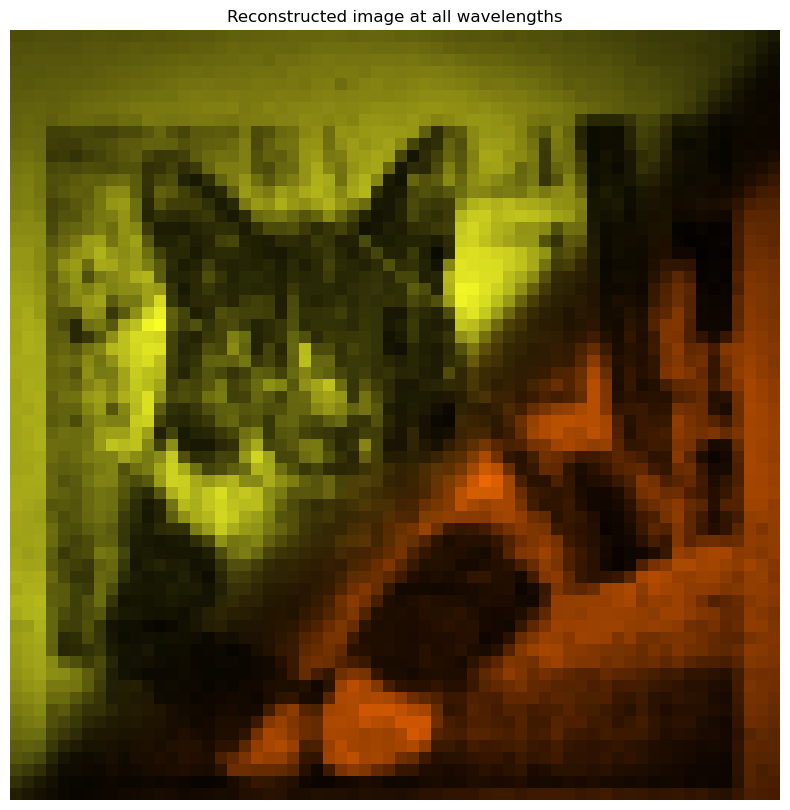

0 [0, 0, 0]
1 [1688, 0, 0]
2 [1688, 2547, 0]
Returning [1688, 2547, 1816] as estimated pure pixel indices


In [ ]:
# This will be in the slides
# load with torch
data = np.load("../tensorly_hdr/dataset/cat_HSI_reconstructed.npz")
# convert to pytorch tensor
X_rec = torch.tensor(data["X_rec"], dtype=torch.float32)
wavelengths_nz = data["wavelengths"]

# Show cat in fake three colors from the hyperspectral cube X_rec
plt.figure(figsize=(12,10))
# make a mapping between hyperspectral and RGB values, for visualization only

def rgb_filters(wavelengths):
    r_filter = torch.exp(-0.5 * ((wavelengths - 575) / 50) ** 2)
    g_filter = torch.exp(-0.5 * ((wavelengths - 535) / 50) ** 2)
    b_filter = torch.exp(-0.5 * ((wavelengths - 445) / 50) ** 2)
    return torch.stack([r_filter, g_filter, b_filter])

# RGB cube
filters = rgb_filters(torch.tensor(wavelengths_nz, dtype=torch.float32))
rgb_cube = filters @ X_rec  # shape (3, N**2)
# Make into RGB image
rgb_image = rgb_cube.reshape((3, img_size, img_size))
rgb_image = rgb_image / torch.max(rgb_image)  # normalize for visualization
# make shape N N 3
rgb_image = np.transpose(rgb_image, (1, 2, 0))
plt.imshow(np.rot90(rgb_image, 2))
plt.title("Reconstructed image at all wavelengths")
plt.axis('off')
plt.show()


In [ ]:
# Processing with NMF
rank = 3
Kset, W0, A0 = snpa(X_rec, rank, verbose=True)

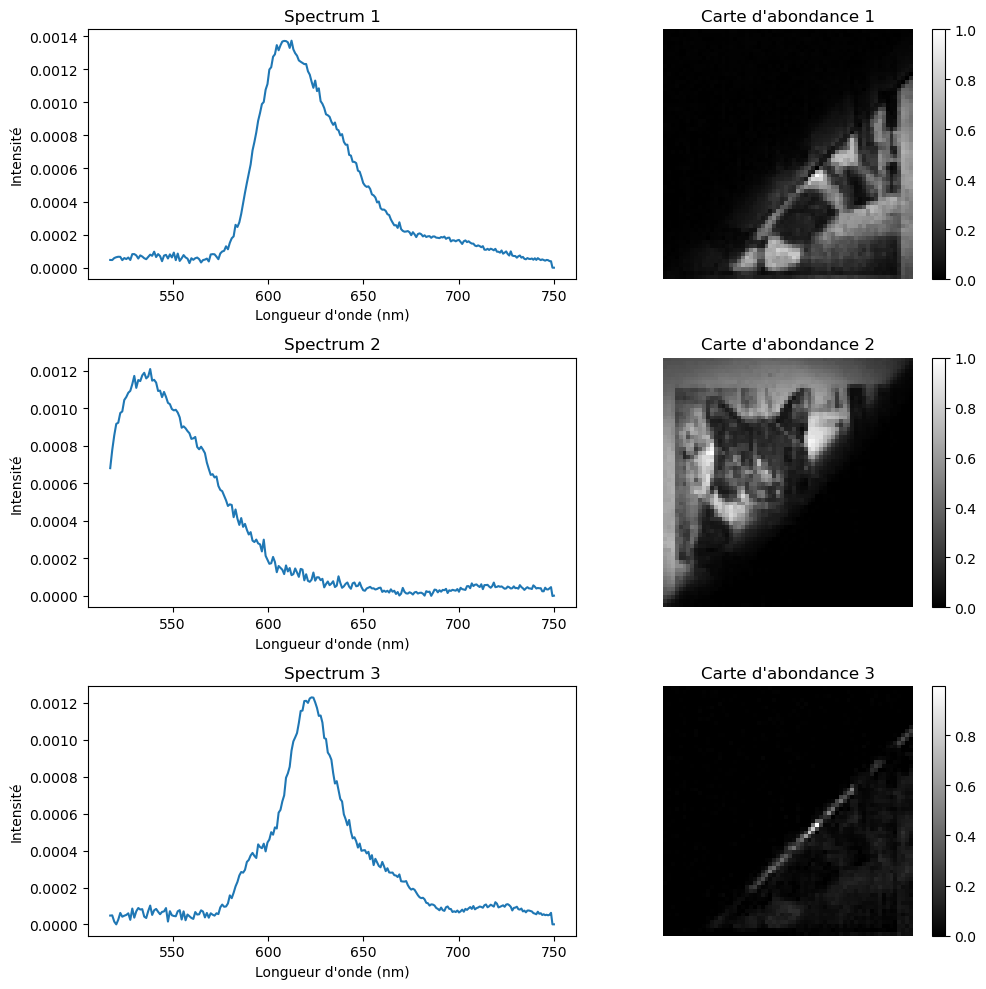

In [44]:
# Plotting results

A0norms = [torch.max(A0[i,:]) for i in range(rank)]
# show hypercube at some wavelengths and some spectra
plt.figure(figsize=(10,10))
for i in range(rank):
    plt.subplot(rank,2,2*i+1)
    plt.plot(wavelengths_nz, A0norms[i]*W0[:,i].cpu().numpy())
    plt.title(f"Spectrum {i+1}")
    plt.xlabel("Longueur d'onde (nm)")
    plt.ylabel("Intensité") 
    plt.subplot(rank,2,2*i+2)
    plt.imshow(np.rot90(A0[i,:].reshape(64,64), 2), cmap='gray')
    plt.title(f"Carte d'abondance {i+1}")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis('off')
    plt.tight_layout()
plt.show()

Slide adaptation of the code for the HRSI

In [ ]:
import numpy as np
import plotly.graph_objects as go
import tensorly as tl
import matplotlib
import matplotlib.pyplot as plt

# Generating toy image
n1 = 30
n2 = 40
r = 3
sig = 0.2  # 0.15 # 0.05

# Components will be Gaussian distributions, here is the macro to generate them
def gauss(x, m, sig, thresh=0.1):
    # max is 1
    out = np.exp(-(x-m)**2/sig**2)
    out[out < thresh] = 0
    return out

# Generating the data as a mixture of separable Gaussians
x = np.linspace(0, n1-1, n1) # 1D abcisse
y = np.linspace(0, n2-1, n2)
W = np.zeros([n1, r])
W[:,0] = gauss(x, 5, 3)
W[:,1] = gauss(x, 15, 5)
W[:,2] = gauss(x, 25, 10)
H = np.zeros([n2, r])
H[:, 0] = gauss(y, 10, 5)
H[:, 1] = gauss(y, 20, 6)
H[:, 2] = gauss(y, 25, 5)
trueNMF = (None, [W, H])

Y = W@H.T  # NMF model
rng = np.random.default_rng(1246)
Yn = Y + sig*rng.random((n1, n2))  # corruption with gaussian noise

# initialization 
W0 = 0*W + 0.5*rng.random(W.shape)
H0 = 0*H + 0.5*rng.random(H.shape)

# Storing output factors for various regularization in dictionaries
We = dict()
He = dict()

# Chose the grid values for the hyperparameter 
lambset = [0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.6, 0.7, 0.75, 0.78, 0.8, 1, 1.2, 1.5, 2, 3, 4, 5, 5.2, 6, 20]

import copy
for lamb in lambset:
    # Computing the sparse NMF with tensorly (the algorithm is HALS, which is the state of the art for this problem)
    out = tl.decomposition.non_negative_parafac_hals(Yn, r, sparsity_coefficients=[lamb, lamb], init=copy.deepcopy((None, [W0, H0])))
    # Estimated factors
    We[lamb] = out[1][0]
    He[lamb] = out[1][1]
    # Set estimates as new initialization for the next iteration (warm start)
    W0 = We[lamb]
    H0 = He[lamb]
    
    # rescale We so that when a column of W is 0, so is the corresponding column of H
    norms = tl.max(We[lamb], axis=0)
    for q in range(r):
        if norms[q] > 1e-8:
            We[lamb][:, q] = We[lamb][:, q]/norms[q]
            He[lamb][:, q] = He[lamb][:, q]*norms[q]
        else:
            We[lamb][:, q] = We[lamb][:, q]*0
            He[lamb][:, q] = He[lamb][:, q]*0


# --------------------------------------------------
# Pack all computed factors into one array
# shape = (n_lambda, n1, r)
# --------------------------------------------------

Wall = np.stack([We[lam] for lam in lambset])

colors = ["blue", "green", "red"]

# --------------------------------------------------
# Initial traces (lambda = lambset[0])
# --------------------------------------------------

fig = go.Figure()

for q in range(r):
    fig.add_trace(
        go.Scatter(
            x=x,
            y=Wall[0, :, q],
            mode="lines",
            name=f"Component {q+1}",
            line=dict(color=colors[q]),
        )
    )

# --------------------------------------------------
# Slider steps
# --------------------------------------------------

steps = []

for k, lam in enumerate(lambset):

    step = dict(
        method="update",
        args=[
            {
                "y": [
                    Wall[k, :, 0],
                    Wall[k, :, 1],
                    Wall[k, :, 2],
                ]
            },
            {
                "title": f"Regularization λ = {lam}"
            }
        ],
        label=str(lam),
    )

    steps.append(step)

# --------------------------------------------------
# Layout
# --------------------------------------------------

fig.update_layout(
    title=f"Regularization λ = {lambset[0]}",
    width=800,
    height=450,
    xaxis_title="Index",
    yaxis_title="Amplitude",
    template="simple_white",
    sliders=[
        dict(
            active=0,
            currentvalue={
                "prefix": "λ = ",
                "font": {"size": 16},
            },
            pad={"t": 40},
            steps=steps,
        )
    ],
    legend=dict(
        x=0.90,
        y=0.99,
    ),
)

ValueError: Invalid property specified for object of type plotly.graph_objs.Scatter: 'width'

Did you mean "ids"?

    Valid properties:
        alignmentgroup
            Set several traces linked to the same position axis or
            matching axes to the same alignmentgroup. This controls
            whether bars compute their positional range dependently
            or independently.
        cliponaxis
            Determines whether or not markers and text nodes are
            clipped about the subplot axes. To show markers and
            text nodes above axis lines and tick labels, make sure
            to set `xaxis.layer` and `yaxis.layer` to *below
            traces*.
        connectgaps
            Determines whether or not gaps (i.e. {nan} or missing
            values) in the provided data arrays are connected.
        customdata
            Assigns extra data each datum. This may be useful when
            listening to hover, click and selection events. Note
          

In [1]:
import numpy as np
import plotly.graph_objects as go
import tensorly as tl

from copy import deepcopy
from tensorly.solvers.penalizations import scale_factors_fro
from tensorly.decomposition import non_negative_parafac_hals


# ============================================================
# Utilities
# ============================================================

def optimal_balancing(factors):
    rank = factors[0].shape[1]
    beta = []

    for q in range(rank):
        beta.append(
            tl.prod(
                [tl.norm(factor[:, q]) ** (1 / len(factors))
                 for factor in factors]
            )
        )

    balanced_factors = []

    for i in range(len(factors)):
        balanced_factor = factors[i].copy()

        for q in range(rank):
            balanced_factor[:, q] = (
                factors[i][:, q]
                * beta[q]
                / tl.norm(factors[i][:, q])
            )

        balanced_factors.append(balanced_factor)

    return balanced_factors


# ============================================================
# Problem setup
# ============================================================

rank = 3
dims = [10, 11, 12]
ndims = len(dims)

noise = 0.1
itermax = 100

np.random.seed(22)

true_factors = [
    tl.tensor(np.random.rand(dims[i], rank))
    for i in range(ndims)
]

CPtensor = tl.cp_tensor.CPTensor(
    ([10 ** (-i) for i in range(ndims)], true_factors)
)

data = (
    CPtensor.to_tensor()
    + noise * tl.tensor(np.random.randn(*dims))
)

# Overestimated initialization rank
rank_e = rank + 3

init = [
    10 ** (-i) * tl.tensor(np.random.rand(dims[i], rank_e))
    for i in range(ndims)
]

CPinit = tl.cp_tensor.CPTensor((None, init))

# ============================================================
# Lambda grid
# ============================================================

lambda_values = np.logspace(-4, 2, 20)

all_loss_unscaled = []
all_loss_scaled_balanced = []

# ============================================================
# Run all experiments
# ============================================================

for ridge_reg in lambda_values:

    print(f"Running λ = {ridge_reg:.3e}")

    # Scaling
    CPinit_scaled, scale = scale_factors_fro(
        CPinit,
        data,
        [ridge_reg] * ndims,
        [0] * ndims,
        nonnegative=True,
    )

    init_scaled = CPinit_scaled.factors

    # Balancing
    balanced_scaled_init = optimal_balancing(init_scaled)

    CPinit_scaled_balanced = tl.cp_tensor.CPTensor(
        (None, balanced_scaled_init)
    )

    # -------------------------
    # Unscaled run
    # -------------------------

    callback_loss = []

    def callback_unscaled(factors, unnormalized_rec_errors):
        loss = (
            (unnormalized_rec_errors ** 2) / 2
            + sum(
                ridge_reg * tl.norm(factors[1][i]) ** 2
                for i in range(ndims)
            )
        )
        callback_loss.append(float(loss))

    non_negative_parafac_hals(
        data,
        rank_e,
        n_iter_max=itermax,
        tol=0,
        init=deepcopy(CPinit),
        verbose=False,
        ridge_coefficients=ridge_reg,
        callback=callback_unscaled,
    )

    loss_unscaled = np.asarray(callback_loss)

    # -------------------------
    # Scaled + balanced run
    # -------------------------

    callback_loss = []

    def callback_scaled(factors, unnormalized_rec_errors):
        loss = (
            (unnormalized_rec_errors ** 2) / 2
            + sum(
                ridge_reg * tl.norm(factors[1][i]) ** 2
                for i in range(ndims)
            )
        )
        callback_loss.append(float(loss))

    non_negative_parafac_hals(
        data,
        rank_e,
        n_iter_max=itermax,
        tol=0,
        init=deepcopy(CPinit_scaled_balanced),
        verbose=False,
        ridge_coefficients=ridge_reg,
        callback=callback_scaled,
    )

    loss_scaled_balanced = np.asarray(callback_loss)

    all_loss_unscaled.append(loss_unscaled)
    all_loss_scaled_balanced.append(loss_scaled_balanced)


# ============================================================
# Build Plotly figure
# ============================================================

fig = go.Figure()

for k, lam in enumerate(lambda_values):

    loss1 = all_loss_unscaled[k]
    loss2 = all_loss_scaled_balanced[k]

    visible = (k == 0)

    fig.add_trace(
        go.Scatter(
            x=np.arange(len(loss1)),
            y=loss1,
            mode="lines",
            line=dict(dash="dashdot"),
            name="Without scaling or balancing",
            visible=visible,
        )
    )

    fig.add_trace(
        go.Scatter(
            x=np.arange(len(loss2)),
            y=loss2,
            mode="lines",
            name="With scaling + balancing",
            visible=visible,
        )
    )

# ============================================================
# Slider
# ============================================================

steps = []

for k, lam in enumerate(lambda_values):

    visible = [False] * (2 * len(lambda_values))

    visible[2 * k] = True
    visible[2 * k + 1] = True

    step = dict(
        method="update",
        args=[
            {"visible": visible},
            {
                "title":
                    f"NCPD with ℓ₂ regularization "
                    f"(λ = {lam:.2e})"
            },
        ],
        label=f"{lam:.1e}",
    )

    steps.append(step)

sliders = [
    dict(
        active=0,
        currentvalue={
            "prefix": "λ = "
        },
        pad={"t": 50},
        steps=steps,
    )
]

# ============================================================
# Layout
# ============================================================

fig.update_layout(
    title=f"NCPD with ℓ₂ regularization (λ = {lambda_values[0]:.2e})",
    sliders=sliders,
    xaxis_title="Iteration",
    yaxis_title="Cost function",
    template="plotly_white",
    legend=dict(
        x=0.01,
        y=0.99,
    ),
    height=500,
)

fig.update_yaxes(type="log")

fig.show()


Running λ = 1.000e-04
Running λ = 2.069e-04
Running λ = 4.281e-04
Running λ = 8.859e-04
Running λ = 1.833e-03
Running λ = 3.793e-03
Running λ = 7.848e-03
Running λ = 1.624e-02
Running λ = 3.360e-02
Running λ = 6.952e-02
Running λ = 1.438e-01
Running λ = 2.976e-01
Running λ = 6.158e-01
Running λ = 1.274e+00
Running λ = 2.637e+00
Running λ = 5.456e+00
Running λ = 1.129e+01
Running λ = 2.336e+01
Running λ = 4.833e+01
Running λ = 1.000e+02


In [3]:
import numpy as np
import tensorly as tl

from copy import deepcopy
from plotly.subplots import make_subplots
import plotly.graph_objects as go

from tensorly.solvers.penalizations import scale_factors_fro
from tensorly.decomposition import non_negative_parafac_hals


# ============================================================
# Balancing routine
# ============================================================

def optimal_balancing(factors):
    rank = factors[0].shape[1]

    beta = []
    for q in range(rank):
        beta.append(
            tl.prod(
                [
                    tl.norm(factor[:, q]) ** (1 / len(factors))
                    for factor in factors
                ]
            )
        )

    balanced_factors = []

    for i in range(len(factors)):
        balanced_factor = factors[i].copy()

        for q in range(rank):
            balanced_factor[:, q] = (
                factors[i][:, q]
                * beta[q]
                / tl.norm(factors[i][:, q])
            )

        balanced_factors.append(balanced_factor)

    return balanced_factors


# ============================================================
# Problem setup
# ============================================================

rank = 3
dims = [10, 11, 12]
ndims = len(dims)

noise = 0.1
itermax = 100

np.random.seed(22)

true_factors = [
    tl.tensor(np.random.rand(dims[i], rank))
    for i in range(ndims)
]

CPtensor = tl.cp_tensor.CPTensor(
    ([10 ** (-i) for i in range(ndims)], true_factors)
)

data = (
    CPtensor.to_tensor()
    + noise * tl.tensor(np.random.randn(*dims))
)

# ============================================================
# Initialization
# ============================================================

rank_e = rank + 3

init = [
    10 ** (-i) * tl.tensor(np.random.rand(dims[i], rank_e))
    for i in range(ndims)
]

CPinit = tl.cp_tensor.CPTensor((None, init))

# ============================================================
# Lambda values to compare
# ============================================================

lambda_values = [1e-4, 1.4e-1]

results = {}

# ============================================================
# Run experiments
# ============================================================

for ridge_reg in lambda_values:

    print(f"Running λ = {ridge_reg:.2e}")

    # Scaling
    CPinit_scaled, scale = scale_factors_fro(
        CPinit,
        data,
        [ridge_reg] * ndims,
        [0] * ndims,
        nonnegative=True,
    )

    init_scaled = CPinit_scaled.factors

    # Balancing
    balanced_scaled_init = optimal_balancing(init_scaled)

    CPinit_scaled_balanced = tl.cp_tensor.CPTensor(
        (None, balanced_scaled_init)
    )

    # ========================================================
    # Unscaled initialization
    # ========================================================

    callback_loss = []

    def callback_unscaled(factors, unnormalized_rec_errors):
        loss = (
            (unnormalized_rec_errors ** 2) / 2
            + sum(
                ridge_reg * tl.norm(factors[1][i]) ** 2
                for i in range(ndims)
            )
        )
        callback_loss.append(float(loss))

    non_negative_parafac_hals(
        data,
        rank_e,
        n_iter_max=itermax,
        tol=0,
        init=deepcopy(CPinit),
        verbose=False,
        ridge_coefficients=ridge_reg,
        callback=callback_unscaled,
    )

    loss_unscaled = np.asarray(callback_loss)

    # ========================================================
    # Scaled + balanced initialization
    # ========================================================

    callback_loss = []

    def callback_scaled(factors, unnormalized_rec_errors):
        loss = (
            (unnormalized_rec_errors ** 2) / 2
            + sum(
                ridge_reg * tl.norm(factors[1][i]) ** 2
                for i in range(ndims)
            )
        )
        callback_loss.append(float(loss))

    non_negative_parafac_hals(
        data,
        rank_e,
        n_iter_max=itermax,
        tol=0,
        init=deepcopy(CPinit_scaled_balanced),
        verbose=False,
        ridge_coefficients=ridge_reg,
        callback=callback_scaled,
    )

    loss_scaled_balanced = np.asarray(callback_loss)

    results[ridge_reg] = {
        "loss": loss_unscaled,
        "loss_scaled_balanced": loss_scaled_balanced,
    }


# ============================================================
# Plotly figure
# ============================================================

fig = make_subplots(
    rows=1,
    cols=2,
    shared_yaxes=True,
    horizontal_spacing=0.08,
    subplot_titles=[
        "λ = 10⁻⁴",
        "λ = 1.4 × 10⁻¹",
    ],
)

for col, lam in enumerate(lambda_values, start=1):

    loss = results[lam]["loss"]
    loss_scaled_balanced = results[lam]["loss_scaled_balanced"]

    fig.add_trace(
        go.Scatter(
            x=np.arange(len(loss)),
            y=loss,
            mode="lines",
            line=dict(dash="dashdot"),
            name="Without scaling or balancing",
            showlegend=(col == 1),
        ),
        row=1,
        col=col,
    )

    fig.add_trace(
        go.Scatter(
            x=np.arange(len(loss_scaled_balanced)),
            y=loss_scaled_balanced,
            mode="lines",
            name="With scaling + balancing",
            showlegend=(col == 1),
        ),
        row=1,
        col=col,
    )

fig.update_yaxes(
    type="log",
    title_text="Cost function",
    row=1,
    col=1,
)

fig.update_xaxes(title_text="Iteration")

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=500,
    margin=dict(l=20, r=20, t=70, b=20),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.05,
        xanchor="center",
        x=0.5,
    ),
)

fig.show()



Running λ = 1.00e-04
Running λ = 1.40e-01


In [1]:

import numpy as np
import plotly.graph_objects as go

eps = 0.05
x1 = np.linspace(eps, 4.5, 120)
x2 = np.linspace(eps, 4.5, 120)
X1, X2 = np.meshgrid(x1, x2)

y1 = 1.0
y2_values = [0.4, 1.0, 2.0, 3.5]

def kl2(y1, y2, X1, X2):
    return y1 * np.log(y1 / X1) + X1 - y1 + y2 * np.log(y2 / X2) + X2 - y2

Z0 = kl2(y1, y2_values[0], X1, X2)

fig = go.Figure()

fig.add_trace(
    go.Contour(
        x=x1,
        y=x2,
        z=Z0,
        colorscale="Viridis",
        contours=dict(showlabels=True),
        colorbar=dict(title="D_KL"),
        hovertemplate="x₁=%{x:.2f}<br>x₂=%{y:.2f}<br>KL=%{z:.3f}<extra></extra>",
        name="Perte",
    )
)

fig.add_trace(
    go.Scatter(
        x=[y1],
        y=[y2_values[0]],
        mode="markers",
        marker=dict(color="red", size=12, symbol="x"),
        name="Minimum",
        hovertemplate="minimum : (%{x:.2f}, %{y:.2f})<extra></extra>",
    )
)

frames = []
for y2 in y2_values:
    Z = kl2(y1, y2, X1, X2)
    frames.append(
        go.Frame(
            name=f"{y2}",
            data=[
                go.Contour(
                    x=x1,
                    y=x2,
                    z=Z,
                    colorscale="Viridis",
                    contours=dict(showlabels=True),
                    colorbar=dict(title="D_KL"),
                ),
                go.Scatter(
                    x=[y1],
                    y=[y2],
                    mode="markers",
                    marker=dict(color="red", size=12, symbol="x"),
                ),
            ],
            traces=[0, 1],
        )
    )

fig.frames = frames

fig.update_layout(
    title="Courbes de niveau de la divergence de KL — le minimum est atteint en x = y",
    height=520,
    margin=dict(l=20, r=20, t=70, b=20),
    xaxis_title="x₁",
    yaxis_title="x₂",
    sliders=[
        dict(
            active=0,
            currentvalue={"prefix": "Valeur de y₂ : "},
            pad={"t": 30},
            steps=[
                dict(
                    label=str(y2),
                    method="animate",
                    args=[[f"{y2}"], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}],
                )
                for y2 in y2_values
            ],
        )
    ],
)
fig.show()

In [1]:
import numpy as np
from numpy import size
import matplotlib.pyplot as plt
import numpy as np
import bokeh
from bokeh.layouts import column, row
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import Slider, ColumnDataSource, CustomJS, LogColorMapper
from bokeh.palettes import Category10
output_notebook()

# Showing plots for 1d Kullback Leibler with slider for data position
x = np.linspace(1e-5, 10, 300)

def kl_divergence(p, q):
    """Calculate the KL divergence between two distributions."""
    return np.sum(p * np.log(p / q) + q - p)

y = np.zeros_like(x)
p = 2.5  # Initial reference distribution parameter
for i, q in enumerate(x):
    y[i] = kl_divergence(p, q) 

# Add interactive sliders for the reference distribution
slider = Slider(start=0.1, end=5, value=2.5, step=0.1, title="Reference Distribution (p)")
source = ColumnDataSource(data=dict(x=x, y=y))
plot = figure(title="KL Divergence", x_axis_label='q', y_axis_label='KL(p, q)', width=600,
    height=400)
plot.line('x', 'y', source=source, line_width=2, color=Category10[10][0])
callback = CustomJS(args=dict(source=source, slider=slider), code="""
    const data = source.data;
    const p = slider.value;
    for (let i = 0; i < data['x'].length; i++) {
        const q = data['x'][i];
        data['y'][i] = p * Math.log(p / q) + q - p;  // KL divergence formula
    }
    source.change.emit();
""")
slider.js_on_change('value', callback)
show(column(slider, plot))

Loading BokehJS ...